# Regressão Logística Multiclasse
### Dataset: Student Exam Performance Prediction (Kaggle)

**Objetivo:** Prever a categoria de desempenho do aluno (`Low`, `Medium`, `High`) a partir de variáveis como horas de estudo, presença, pontuações anteriores, etc.

---
## 0. Imports e Configuração

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

torch.manual_seed(42)
np.random.seed(42)

print('PyTorch version:', torch.__version__)

PyTorch version: 2.10.0+cpu


---
## 1. Preparação dos Dados

### 1.1 Carregamento e Compreensão do Dataset

O dataset contém informações sobre alunos e seus desempenhos em exames. A variável target `performance_category` é multiclasse: `Low`, `Medium`, `High`.



In [1]:
!curl -L -o student-exam-performance-prediction.zip \
  https://www.kaggle.com/api/v1/datasets/download/mrsimple07/student-exam-performance-prediction


!unzip -o student-exam-performance-prediction.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 19784  100 19784    0     0  65059      0 --:--:-- --:--:-- --:--:--  197k
Archive:  student-exam-performance-prediction.zip
  inflating: student_exam_data.csv   
  inflating: student_exam_data_new.csv  


In [5]:
df = pd.read_csv('student_exam_data.csv')

print('Shape:', df.shape)
print('\nColunas:', df.columns.tolist())
df.head()

Shape: (500, 3)

Colunas: ['Study Hours', 'Previous Exam Score', 'Pass/Fail']


,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [6]:
print(df.dtypes)
print('\nValores nulos:')
print(df.isnull().sum())

Study Hours            float64
Previous Exam Score    float64
Pass/Fail                int64
dtype: object

Valores nulos:
Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64


In [7]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


### 1.2 Criação da Variável Target Multiclasse

Criamos a coluna `performance_category` a partir de `Exam_Score` usando percentis para balancear as classes.

Distribuição das classes:
performance_category
High      170
Medium    165
Low       165
Name: count, dtype: int64


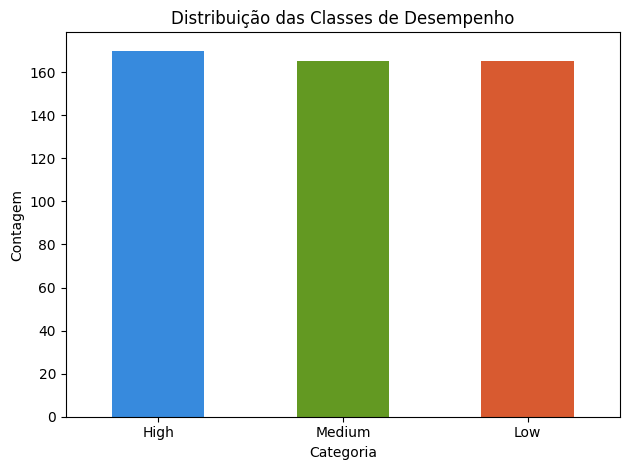

In [9]:
low_thresh  = df['Previous Exam Score'].quantile(0.33)
high_thresh = df['Previous Exam Score'].quantile(0.66)

def categorize(score):
    if score <= low_thresh:
        return 'Low'
    elif score <= high_thresh:
        return 'Medium'
    else:
        return 'High'

df['performance_category'] = df['Previous Exam Score'].apply(categorize)

print('Distribuição das classes:')
print(df['performance_category'].value_counts())

df['performance_category'].value_counts().plot(kind='bar', color=['#378ADD','#639922','#D85A30'])
plt.title('Distribuição das Classes de Desempenho')
plt.xlabel('Categoria')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.3 Encoding de Variáveis Categóricas

In [10]:
df_encoded = df.copy()

# Colunas categóricas (exceto target)
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'performance_category']
print('Colunas categóricas:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Encoding do target
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_encoded['target'] = df_encoded['performance_category'].map(label_map)

print('\nMapeamento do target:', label_map)
df_encoded.head()

Colunas categóricas: []

Mapeamento do target: {'Low': 0, 'Medium': 1, 'High': 2}


,Study Hours,Previous Exam Score,Pass/Fail,performance_category,target
0,4.370861,81.889703,0,High,2
1,9.556429,72.165782,1,Medium,1
2,7.587945,58.571657,0,Medium,1
3,6.387926,88.827701,1,High,2
4,2.404168,81.083870,0,High,2


### 1.4 Separação Features e Target

In [12]:
drop_cols = ['performance_category', 'target']
X = df_encoded.drop(columns=drop_cols).values.astype(np.float32)
y = df_encoded['target'].values.astype(np.int64)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Classes únicas em y:', np.unique(y))

X shape: (500, 3)
y shape: (500,)
Classes únicas em y: [0 1 2]


### 1.5 Divisão Treino / Validação / Teste

In [13]:
# 70% treino | 15% validação | 15% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')

Treino:    350 amostras
Validação: 75 amostras
Teste:     75 amostras


### 1.6 Normalização (StandardScaler)

O scaler é **fitado apenas no treino** e aplicado em validação e teste para evitar data leakage.

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

### 1.7 Conversão para Tensores PyTorch e DataLoaders

In [15]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches por época (treino): {len(train_loader)}')

Batches por época (treino): 6


---
## 2. Construção do Modelo

A Regressão Logística Multiclasse é equivalente a uma rede neural com **uma única camada linear** seguida de **Softmax**.

- A camada `nn.Linear(num_features, num_classes)` gera os **logits** — valores brutos sem normalização.
- O **Softmax** converte os logits em probabilidades que somam 1.
- O `CrossEntropyLoss` do PyTorch já aplica Softmax internamente, então **não adicionamos Softmax ao modelo**.

In [16]:
num_features = X_train_t.shape[1]
num_classes  = 3  # Low, Medium, High

class LogisticRegressionMulticlass(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.linear = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.linear(x)  # retorna logits

model = LogisticRegressionMulticlass(num_features, num_classes)
print(model)
print(f'\nParâmetros treináveis: {sum(p.numel() for p in model.parameters())}')

LogisticRegressionMulticlass(
  (linear): Linear(in_features=3, out_features=3, bias=True)
)

Parâmetros treináveis: 12


**Visualizando logits vs. probabilidades Softmax:**

In [17]:
sample = X_train_t[:3]
with torch.no_grad():
    logits = model(sample)
    probs  = torch.softmax(logits, dim=1)

print('Logits (brutos):')
print(logits)
print('\nProbabilidades Softmax (somam 1 por linha):')
print(probs)
print('\nSoma das probabilidades:', probs.sum(dim=1))

Logits (brutos):
tensor([[-0.3391,  1.2617, -1.0683],
        [ 0.5275,  1.1874,  0.8102],
        [ 0.6597,  1.0724,  0.9773]])

Probabilidades Softmax (somam 1 por linha):
tensor([[0.1553, 0.7698, 0.0749],
        [0.2347, 0.4540, 0.3113],
        [0.2574, 0.3889, 0.3537]])

Soma das probabilidades: tensor([1., 1., 1.])


---
## 3. Configuração do Treinamento

In [19]:
# CrossEntropyLoss = LogSoftmax + NLLLoss
criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 0.1
NUM_EPOCHS    = 50

optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

print(f'Função de perda: {criterion}')
print(f'Otimizador:      SGD | lr={LEARNING_RATE}')
print(f'Épocas:          {NUM_EPOCHS}')

Função de perda: CrossEntropyLoss()
Otimizador:      SGD | lr=0.1
Épocas:          50


---
## 4. Treinamento da Rede

In [20]:
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

for epoch in range(NUM_EPOCHS):

    # ---- TREINO ----
    model.train()
    batch_losses, batch_correct, batch_total = [], 0, 0

    for X_batch, y_batch in train_loader:
        # 1. Forward pass
        logits = model(X_batch)

        # 2. Cálculo da perda
        loss = criterion(logits, y_batch)

        # 3. Backpropagation
        optimizer.zero_grad()
        loss.backward()

        # 4. Atualização dos parâmetros
        optimizer.step()

        batch_losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        batch_correct += (preds == y_batch).sum().item()
        batch_total   += y_batch.size(0)

    train_loss = np.mean(batch_losses)
    train_acc  = batch_correct / batch_total

    # ---- VALIDAÇÃO ----
    model.eval()
    val_batch_losses, val_correct, val_total = [], 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            val_batch_losses.append(loss.item())
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += y_batch.size(0)

    val_loss = np.mean(val_batch_losses)
    val_acc  = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f'Época [{epoch+1:3d}/{NUM_EPOCHS}] '
              f'| Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} '
              f'| Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

Época [ 10/50] | Train Loss: 0.5011 | Val Loss: 0.5589 | Train Acc: 0.8114 | Val Acc: 0.8000
Época [ 20/50] | Train Loss: 0.4028 | Val Loss: 0.4779 | Train Acc: 0.8743 | Val Acc: 0.8267
Época [ 30/50] | Train Loss: 0.3487 | Val Loss: 0.4322 | Train Acc: 0.9086 | Val Acc: 0.8667
Época [ 40/50] | Train Loss: 0.3239 | Val Loss: 0.4017 | Train Acc: 0.9314 | Val Acc: 0.8667
Época [ 50/50] | Train Loss: 0.2991 | Val Loss: 0.3779 | Train Acc: 0.9343 | Val Acc: 0.8933


---
## 5. Avaliação do Modelo

### 5.1 Curvas de Aprendizado (Loss e Acurácia)

Usamos as curvas de treino vs. validação para identificar overfitting ou underfitting.

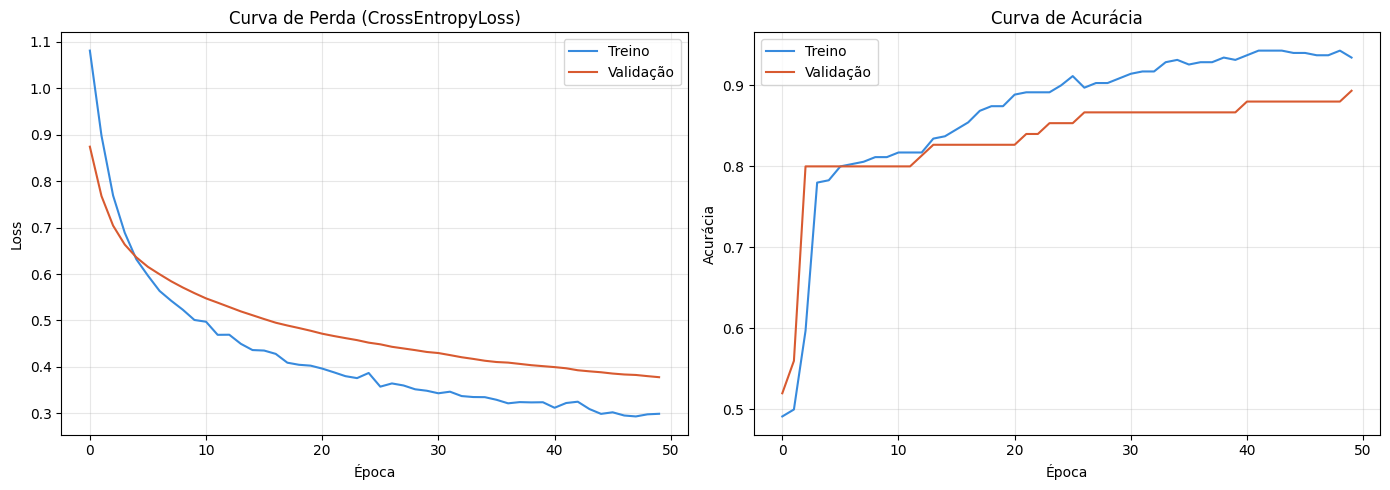

Loss final  — Treino: 0.2991 | Validação: 0.3779 | Gap: 0.0788
Acurácia final — Treino: 0.9343 | Validação: 0.8933

⚠ Possível OVERFITTING: loss de validação significativamente maior que a de treino.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Treino',    color='#378ADD')
axes[0].plot(val_losses,   label='Validação', color='#D85A30')
axes[0].set_title('Curva de Perda (CrossEntropyLoss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Acurácia
axes[1].plot(train_accs, label='Treino',    color='#378ADD')
axes[1].plot(val_accs,   label='Validação', color='#D85A30')
axes[1].set_title('Curva de Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnóstico
gap_loss = abs(train_losses[-1] - val_losses[-1])
print(f'Loss final  — Treino: {train_losses[-1]:.4f} | Validação: {val_losses[-1]:.4f} | Gap: {gap_loss:.4f}')
print(f'Acurácia final — Treino: {train_accs[-1]:.4f} | Validação: {val_accs[-1]:.4f}')

if val_losses[-1] > train_losses[-1] * 1.1:
    print('\n⚠ Possível OVERFITTING: loss de validação significativamente maior que a de treino.')
elif train_accs[-1] < 0.7:
    print('\n⚠ Possível UNDERFITTING: acurácia de treino ainda baixa.')
else:
    print('\n✓ Modelo aparenta estar bem ajustado.')

### 5.2 Avaliação no Conjunto de Teste

In [22]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        # Conversão dos logits em classes previstas
        preds  = torch.argmax(logits, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f'Acurácia no Teste: {test_acc:.4f}')

class_names = ['Low', 'Medium', 'High']
print('\nRelatório de Classificação:')
print(classification_report(all_labels, all_preds, target_names=class_names))

Acurácia no Teste: 0.9467

Relatório de Classificação:
              precision    recall  f1-score   support

         Low       0.89      1.00      0.94        25
      Medium       1.00      0.84      0.91        25
        High       0.96      1.00      0.98        25

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



### 5.3 Matriz de Confusão

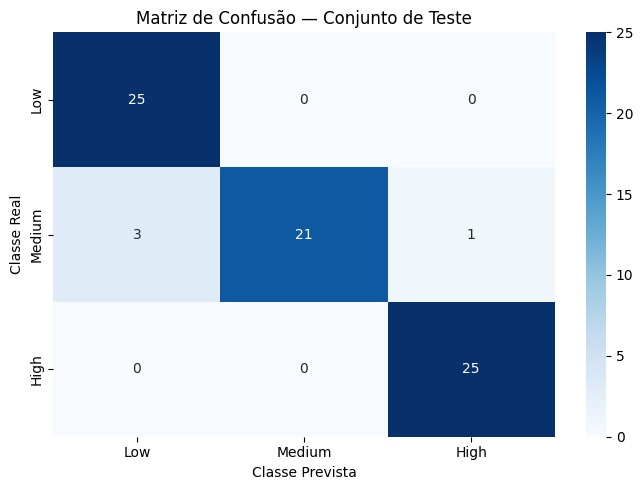

In [24]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão — Conjunto de Teste')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()